# 🎵 Spotify Tracks — Exploratory Data Analysis

This notebook explores the Spotify Tracks Dataset before clustering.
Goals:
1. Understand the distribution of each audio feature
2. Check for missing values and outliers
3. Examine how features correlate with each other
4. Peek at genre-level differences to validate that clustering is meaningful
5. Visualize two features in 2D to build intuition

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

DATA_PATH = '../data/spotify_songs.csv'

# 1. Load the Data Set

In [4]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (32833, 23)


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [5]:
df.info()
print('\nMissing values per column:')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

# 2. Audio Feature Distributions

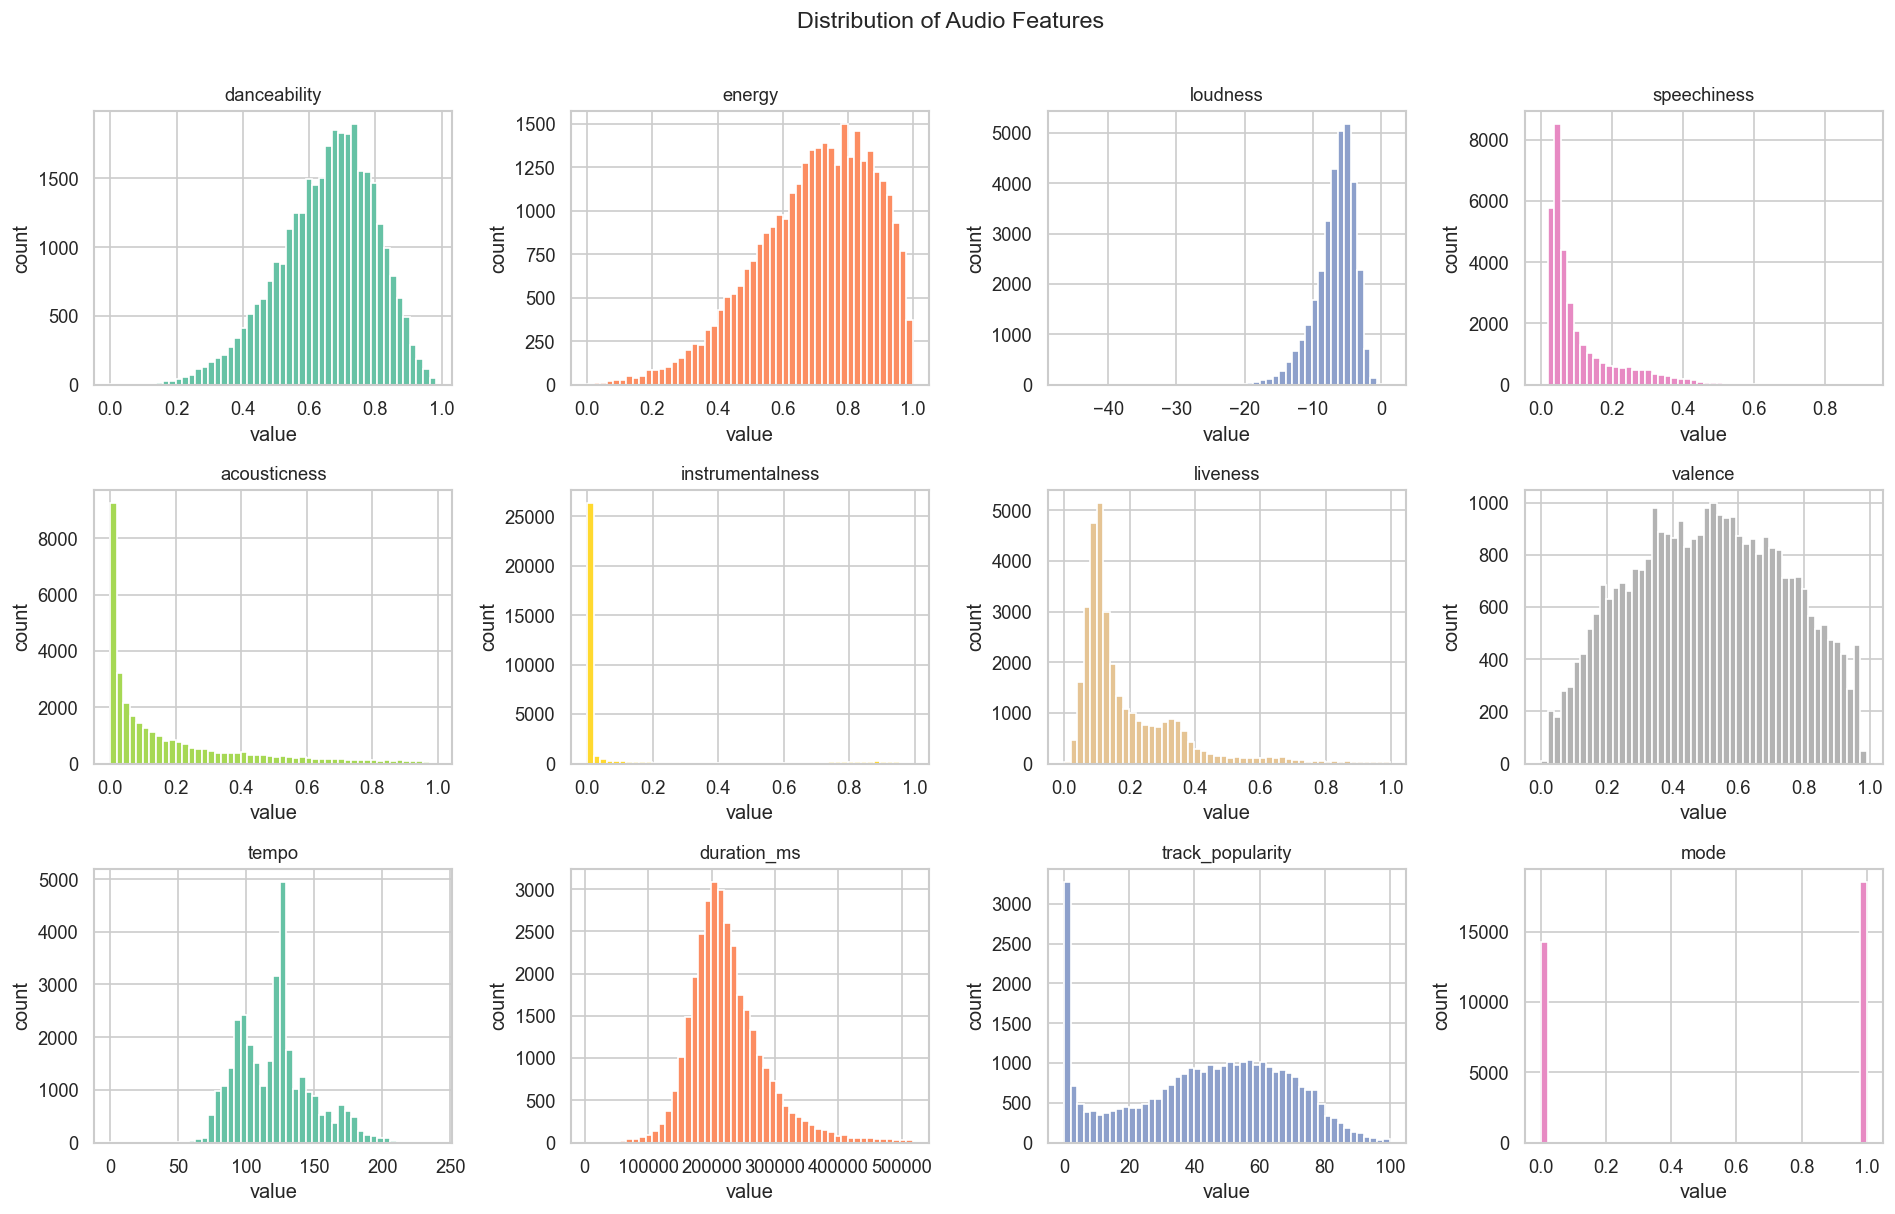

In [6]:
AUDIO_FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'duration_ms', 'track_popularity', 'mode'
]

# Keep only features that exist in this CSV version
features = [f for f in AUDIO_FEATURES if f in df.columns]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].hist(df[feat].dropna(), bins=50, color=sns.color_palette('Set2')[i % 8], edgecolor='white')
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('value')
    axes[i].set_ylabel('count')

for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Audio Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 3. Feature Correlation HeatMap

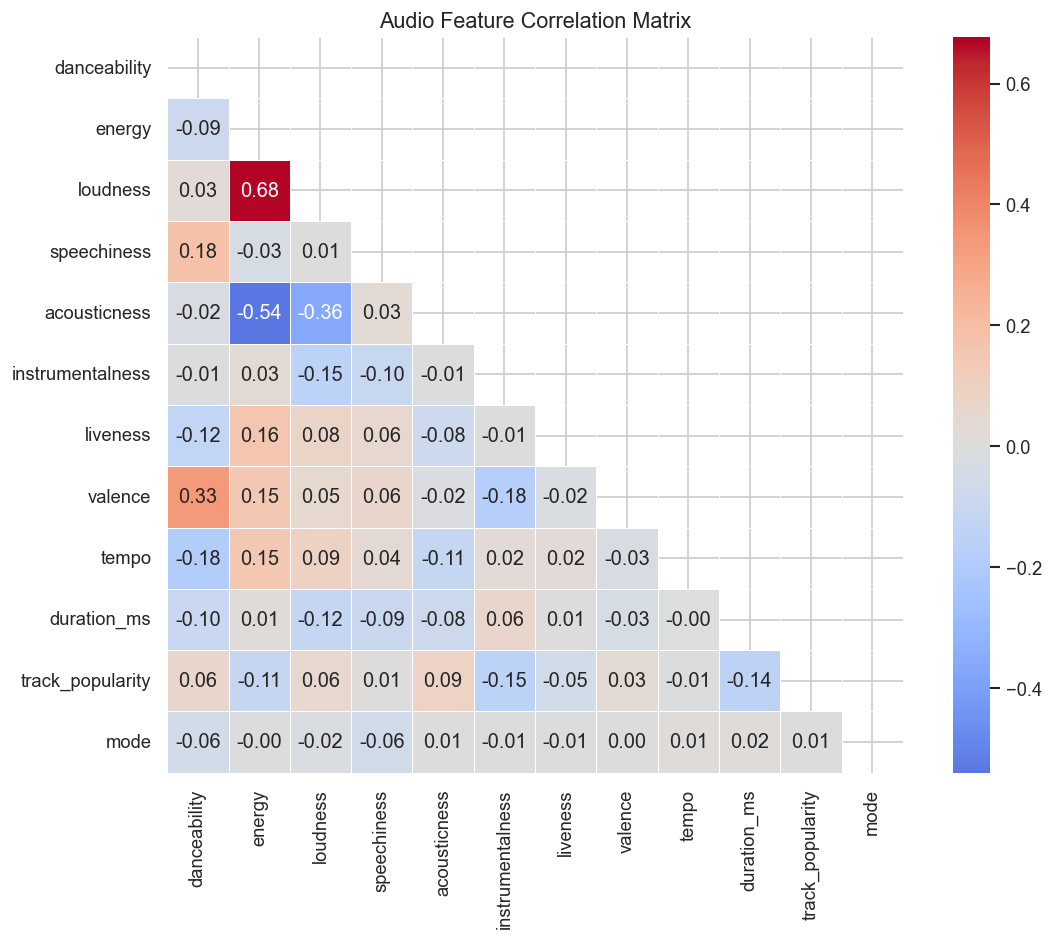


Strongest correlations (|r| > 0.5):
  loudness ↔ energy: r = 0.677
  acousticness ↔ energy: r = -0.540
  energy ↔ loudness: r = 0.677
  energy ↔ acousticness: r = -0.540


In [7]:
corr = df[features].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))   # show only lower triangle
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    square=True, linewidths=0.5
)
plt.title('Audio Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

print('\nStrongest correlations (|r| > 0.5):')
for col in corr.columns:
    for row in corr.index:
        r = corr.loc[row, col]
        if row != col and abs(r) > 0.5:
            print(f'  {row} ↔ {col}: r = {r:.3f}')

## 4. Genre-Level Feature Comparison

If genres already differ in audio space, clustering has a good chance
of recovering meaningful groups without seeing genre labels.

/var/folders/ds/52strkfj0yz0lwhp4r48y6yw0000gn/T/ipykernel_90021/2194195503.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/ds/52strkfj0yz0lwhp4r48y6yw0000gn/T/ipykernel_90021/2194195503.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/ds/52strkfj0yz0lwhp4r48y6yw0000gn/T/ipykernel_90021/2194195503.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/ds/52strkfj0yz0lwhp4r48y6yw0000gn/T/ipykernel_90021/2194195503.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

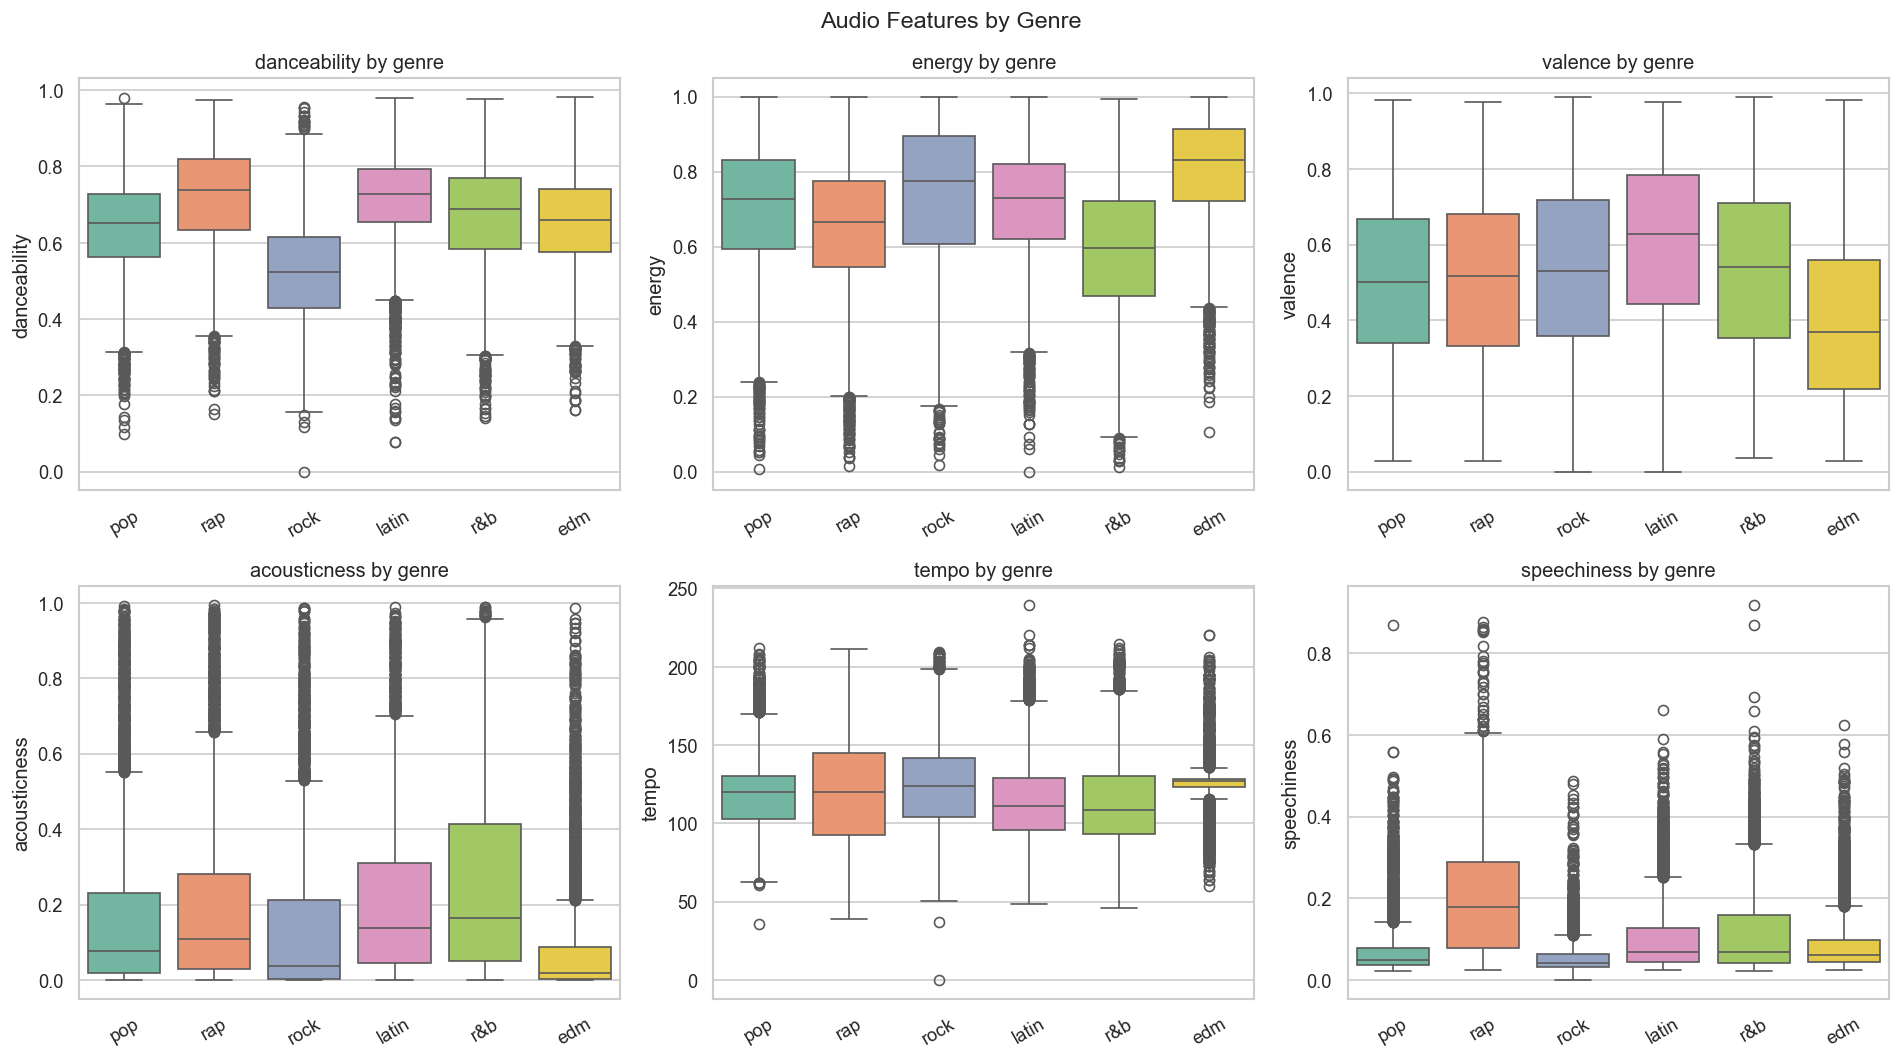

In [8]:
genre_col = 'playlist_genre' if 'playlist_genre' in df.columns else None

if genre_col:
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()
    highlight_features = ['danceability', 'energy', 'valence', 'acousticness', 'tempo', 'speechiness']

    for i, feat in enumerate(highlight_features):
        if feat not in df.columns:
            continue
        sns.boxplot(
            data=df, x=genre_col, y=feat,
            palette='Set2', ax=axes[i]
        )
        axes[i].set_title(f'{feat} by genre')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=30)

    plt.suptitle('Audio Features by Genre', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('No genre column found — skipping genre comparison.')

## 5. Popularity Distribution

One motivation for acoustic-feature clustering: popularity-based recommendations
always surface the same mainstream hits. Our approach is popularity-blind.

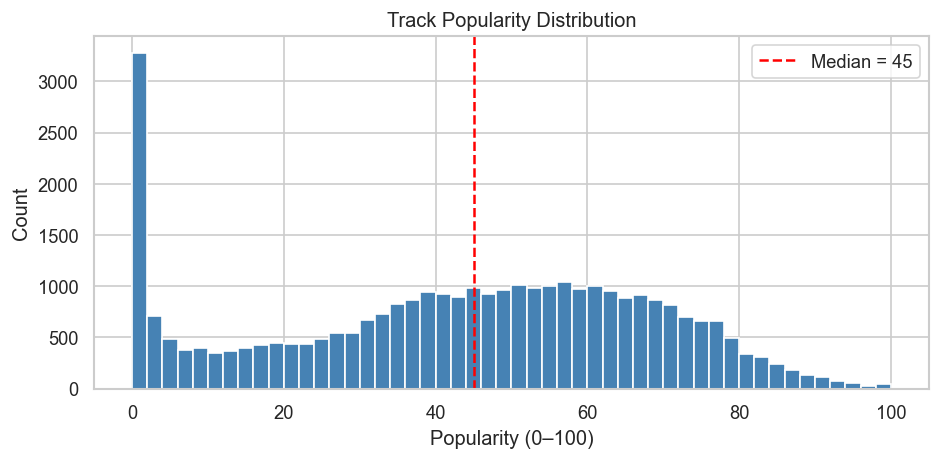

22.0% of tracks have popularity < 20 — hidden gems our app can surface!


In [9]:
if 'track_popularity' in df.columns:
    plt.figure(figsize=(8, 4))
    plt.hist(df['track_popularity'], bins=50, color='steelblue', edgecolor='white')
    plt.axvline(df['track_popularity'].median(), color='red', linestyle='--',
                label=f'Median = {df["track_popularity"].median():.0f}')
    plt.title('Track Popularity Distribution')
    plt.xlabel('Popularity (0–100)')
    plt.ylabel('Count')
    plt.legend()
    plt.tight_layout()
    plt.show()

    pct_obscure = (df['track_popularity'] < 20).mean() * 100
    print(f'{pct_obscure:.1f}% of tracks have popularity < 20 — hidden gems our app can surface!')

## 6. 2D Feature Scatter (Energy vs. Danceability)

A manual look at two features to see if genres are separable in audio space,
building intuition for what k-means will do in 12 dimensions.

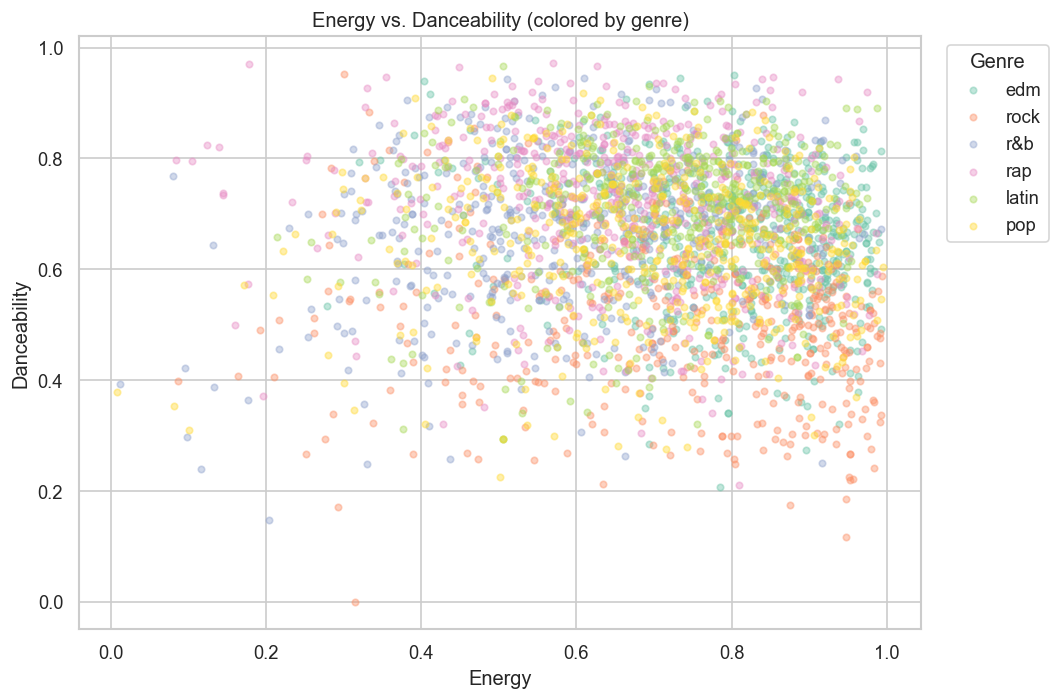

In [10]:
if genre_col and 'energy' in df.columns and 'danceability' in df.columns:
    sample = df.sample(min(3000, len(df)), random_state=42)

    plt.figure(figsize=(9, 6))
    genres = sample[genre_col].unique()
    palette = sns.color_palette('Set2', len(genres))

    for genre, color in zip(genres, palette):
        subset = sample[sample[genre_col] == genre]
        plt.scatter(subset['energy'], subset['danceability'],
                    alpha=0.4, s=15, label=genre, color=color)

    plt.xlabel('Energy')
    plt.ylabel('Danceability')
    plt.title('Energy vs. Danceability (colored by genre)')
    plt.legend(title='Genre', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## 7. Summary Statistics

In [11]:
df[features].describe().round(3)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,track_popularity,mode
count,32833.000,32833.000,32833.000,32833.000,32833.000,32833.000,32833.000,32833.000,32833.000,32833.000,32833.000,32833.000
mean,0.655,0.699,-6.719,0.107,0.175,0.085,0.190,0.511,120.881,225799.812,42.477,0.566
std,0.145,0.181,2.988,0.101,0.220,0.224,0.154,0.233,26.904,59834.006,24.984,0.496
min,0.000,0.000,-46.448,0.000,0.000,0.000,0.000,0.000,0.000,4000.000,0.000,0.000
25%,0.563,0.581,-8.171,0.041,0.015,0.000,0.093,0.331,99.960,187819.000,24.000,0.000
50%,0.672,0.721,-6.166,0.062,0.080,0.000,0.127,0.512,121.984,216000.000,45.000,1.000
75%,0.761,0.840,-4.645,0.132,0.255,0.005,0.248,0.693,133.918,253585.000,62.000,1.000
max,0.983,1.000,1.275,0.918,0.994,0.994,0.996,0.991,239.440,517810.000,100.000,1.000
